In [2]:
%load_ext autoreload
%autoreload 2

# Transformer Model Training 2

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import joblib
import matplotlib.dates as mdates
from sklearn.metrics import  r2_score
import tensorflow as tf
# set up relative imports
project_folder = Path.cwd().parent.parent
sys.path.append(str(project_folder))

In [4]:
from modeling.model.transformer import Transformer, CustomSchedule, get_callbacks
from modeling.utilities.data_prep import setup_sequential_data, create_split_dfs

#### read in data

In [ ]:
data_folder = Path(r'..\..\data\model-ready\water-weather-wind')

# train
train_X_df = pd.read_parquet(data_folder / 'scaled-X-train.parquet')
train_y_df = pd.read_parquet(data_folder / 'Y-train.parquet') 

# test
test_X_df = pd.read_parquet(data_folder / 'scaled-X-test.parquet')
test_y_df = pd.read_parquet(data_folder / 'Y-test.parquet') 

# val
val_X_df = pd.read_parquet(data_folder / 'scaled-X-val.parquet')
val_y_df = pd.read_parquet(data_folder / 'Y-val.parquet') 



In [6]:
scaler = joblib.load(data_folder / 'minmax_scaler.joblib')

#### set up sequential data

In [7]:
train_X_df.reset_index(drop=True, inplace=True)
train_y_df.reset_index(drop=True, inplace=True)

train_df = train_X_df.join(train_y_df)
train_df.head(3)

,WSPD,WDIR,TMAX,TMIN,PRCP,BOT_TEMP_C,SURF_TEMP_C,month,day,year,...,sin_wdir,cos_wdir,wind_u,wind_v,past_10_day_ave_temp,past_10_day_std_temp,wind_u_3day_ave,wind_v_3day_ave,date,target
0,0.288675,0.348866,0.145833,0.279070,0.000000,0.221429,0.169118,0.0,0.033333,0.0,...,0.943951,0.270107,0.122171,0.522877,0.158109,0.042587,0.177094,0.603330,2005-01-02,15.0
1,0.299778,0.352996,0.166667,0.395349,0.461538,0.214286,0.161765,0.0,0.066667,0.0,...,0.938372,0.259640,0.117156,0.531499,0.152676,0.045999,0.120876,0.593809,2005-01-03,14.7
2,0.332443,0.455904,0.041667,0.279070,0.256410,0.192857,0.139706,0.0,0.100000,0.0,...,0.730039,0.056086,0.205262,0.646602,0.143847,0.075283,0.054217,0.641305,2005-01-04,15.0


In [8]:
test_X_df.reset_index(drop=True, inplace=True)
test_y_df.reset_index(drop=True, inplace=True)

test_df = test_X_df.join(test_y_df)
test_df.head(3)
test_df.shape

(851, 26)

In [9]:
val_X_df.reset_index(drop=True, inplace=True)
val_y_df.reset_index(drop=True, inplace=True)

val_df = val_X_df.join(val_y_df)
val_df.head(3)
val_df.shape

(851, 26)

In [10]:
train_dfs = create_split_dfs(train_df)
test_dfs = create_split_dfs(test_df)
val_dfs = create_split_dfs(val_df)

In [11]:
def setup_seq_data_df_list(data_dfs: list[pd.DataFrame], 
                           seq_size: int, 
                           remove_cols: list, 
                           target_col: str
                           ):
    X_trains = []
    y_trains = []
    y_idx = []
    if target_col not in remove_cols:
        remove_cols.append(target_col)
    for df in data_dfs:
        train_cols = list(df.columns)
        for col in remove_cols:
            train_cols.remove(col)
        x_train_df = df[train_cols]
        y_train_df = df[[target_col]]
        X_train, y_train, y_id = setup_sequential_data(x_train_df, y_train_df, seq_size)
        if len(X_train.shape) == 3:
            X_trains.append(X_train)
            y_trains.append(y_train)
            y_idx.append(y_id)

    full_data_x = np.concatenate(X_trains)
    full_data_y = np.concatenate(y_trains)
    full_y_idx = np.concatenate(y_idx)

    return full_data_x, full_data_y, full_y_idx

In [12]:
seq_size=8
X_seq_train, y_seq_train, y_idx_train = setup_seq_data_df_list(train_dfs, seq_size, ['date'], 'target')
X_seq_test, y_seq_test, y_idx_test = setup_seq_data_df_list(test_dfs, seq_size, ['date'], 'target')
X_seq_val, y_seq_val, y_idx_val = setup_seq_data_df_list(val_dfs, seq_size, ['date'], 'target')

##### set up tensorflow datasets

In [13]:
BATCH_SIZE = 32

train_dataset = (
    tf.data.Dataset.from_tensor_slices((X_seq_train, y_seq_train))
    .shuffle(1000)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_dataset = (
    tf.data.Dataset.from_tensor_slices((X_seq_val, y_seq_val))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_dataset = (
    tf.data.Dataset.from_tensor_slices((X_seq_test, y_seq_test))
    .batch(BATCH_SIZE)
)

### Compile and Train the model

In [41]:
num_layers = 4
d_model = 32
dff = 64
num_heads = 4
dropout_rate = 0.1

transformer = Transformer(
    num_layers=num_layers,
    d_model=d_model,
    num_heads=num_heads,
    dff=dff,
    dropout_rate=dropout_rate
    )

In [42]:
dummy = tf.zeros((1, X_seq_train.shape[-2], X_seq_train.shape[-1]))
transformer(dummy)
transformer.summary()

Model: "transformer_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_2 (Encoder)             │ ?                      │        85,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_2 (Decoder)             │ ?                      │       152,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (1, 1)                 │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 238,049 (929.88 KB)

 Trainable params: 238,049 (929.88 KB)

 Non-trainable params: 0 (0.00 B)

In [43]:
transformer.compile(
    loss='mse',
    #optimizer=optimizer,
    optimizer='adam',
    metrics=[
        tf.keras.metrics.MeanAbsoluteError(),
        ]
    )

In [44]:
history = transformer.fit(train_dataset,
                          epochs=50,
                          validation_data=val_dataset,
                          callbacks=get_callbacks()
                )

Epoch 1/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 48s 99ms/step - loss: 102.3181 - mean_absolute_error: 9.4941 - val_loss: 47.1866 - val_mean_absolute_error: 6.2596 - learning_rate: 0.0010
Epoch 2/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 9s 79ms/step - loss: 25.4537 - mean_absolute_error: 4.1606 - val_loss: 10.5900 - val_mean_absolute_error: 2.6391 - learning_rate: 0.0010
Epoch 3/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 10s 81ms/step - loss: 8.4884 - mean_absolute_error: 2.3531 - val_loss: 7.8815 - val_mean_absolute_error: 2.3979 - learning_rate: 0.0010
Epoch 4/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 10s 80ms/step - loss: 4.1071 - mean_absolute_error: 1.4583 - val_loss: 1.9854 - val_mean_absolute_error: 1.0136 - learning_rate: 0.0010
Epoch 5/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 10s 83ms/step - loss: 1.5282 - mean_absolute_error: 0.8578 - val_loss: 1.0421 - val_mean_absolute_error: 0.7532 - learning_rate: 0.0010
Epoch 6/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 9s 79ms/step - loss: 0.9493 - mean_absolute_error: 0.6971 - val_loss: 0.8181

#### Evaluate the model

In [45]:
y_pred = transformer.predict(X_seq_test)

26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 113ms/step


In [46]:
X_seq_test.shape

(827, 8, 24)

In [47]:
test_x_unscaled = scaler.inverse_transform(test_X_df.drop(columns='date'))
test_x_df = pd.DataFrame(columns=test_X_df.drop(columns='date').columns, data=test_x_unscaled)

In [48]:
test_x_df.shape

(851, 24)

In [49]:
y_seq_test.shape

(827,)

In [50]:
results_df = pd.DataFrame({
    'actual': y_seq_test.squeeze(),
    'predicted': y_pred.flatten()
}, index=y_idx_test.flatten())

In [51]:
results_df

,actual,predicted
7,19.90,19.818172
8,21.50,20.468872
9,21.10,20.842503
10,21.10,21.223057
11,21.20,21.531794
...,...,...
846,17.25,16.891212
847,17.10,16.828936
848,17.20,16.893883
849,17.10,16.878801


In [52]:
len(y_pred)

827

In [53]:
test_x_df = test_x_df.join(results_df,
                how='inner')

In [54]:
test_X_df.head(4)

,WSPD,WDIR,TMAX,TMIN,PRCP,BOT_TEMP_C,SURF_TEMP_C,month,day,year,...,cos_day,sin_wdir,cos_wdir,wind_u,wind_v,past_10_day_ave_temp,past_10_day_std_temp,wind_u_3day_ave,wind_v_3day_ave,date
0,0.528497,0.373765,0.500000,0.697674,0.008547,0.321429,0.323529,0.636364,0.666667,1.125,...,0.277951,0.906643,0.209165,-0.012723,0.654143,0.586797,0.485396,0.057067,0.658796,2023-08-21
1,0.065974,0.331611,0.541667,0.674419,0.000000,0.250000,0.316176,0.636364,0.700000,1.125,...,0.373065,0.964529,0.315174,0.274041,0.441355,0.539527,0.505449,0.029180,0.590087,2023-08-22
2,0.096595,0.396162,0.479167,0.720930,0.000000,0.321429,0.352941,0.636364,0.733333,1.125,...,0.473324,0.865968,0.159387,0.267842,0.474030,0.502037,0.481980,0.095791,0.559165,2023-08-23
3,0.101036,0.815871,0.479167,0.697674,0.000000,0.357143,0.352941,0.636364,0.766667,1.125,...,0.574623,0.000083,0.509369,0.411775,0.419587,0.471068,0.460032,0.304467,0.412597,2023-08-24


In [55]:
test_x_df.head(3)

,WSPD,WDIR,TMAX,TMIN,PRCP,BOT_TEMP_C,SURF_TEMP_C,month,day,year,...,sin_wdir,cos_wdir,wind_u,wind_v,past_10_day_ave_temp,past_10_day_std_temp,wind_u_3day_ave,wind_v_3day_ave,actual,predicted
7,0.825000,105.625000,83.0,65.0,0.0,18.0,19.6,8.0,28.0,2023.0,...,0.963045,-0.269340,-0.794512,0.222206,18.195,1.152883,-1.164157,0.471817,19.9,19.818172
8,0.562500,166.666667,84.0,66.0,0.0,19.5,19.9,8.0,29.0,2023.0,...,0.230616,-0.973045,-0.129721,0.547338,18.195,1.152883,-0.835350,0.064603,21.5,20.468872
9,1.808696,229.238095,77.0,68.0,0.0,19.9,21.5,8.0,30.0,2023.0,...,-0.757429,-0.652917,1.369959,1.180928,18.405,1.527243,0.148575,0.650157,21.1,20.842503


In [56]:
test_x_df= test_x_df.join(test_X_df[['date']],
               how='left')

In [57]:
test_x_df[['SURF_TEMP_C', 'actual']].head(8)

,SURF_TEMP_C,actual
7,19.6,19.9
8,19.9,21.5
9,21.5,21.1
10,21.1,21.1
11,21.1,21.2
12,21.2,21.0
13,21.0,22.0
14,22.0,20.6


In [58]:
test_x_df['errors'] = test_x_df.predicted - test_x_df.actual

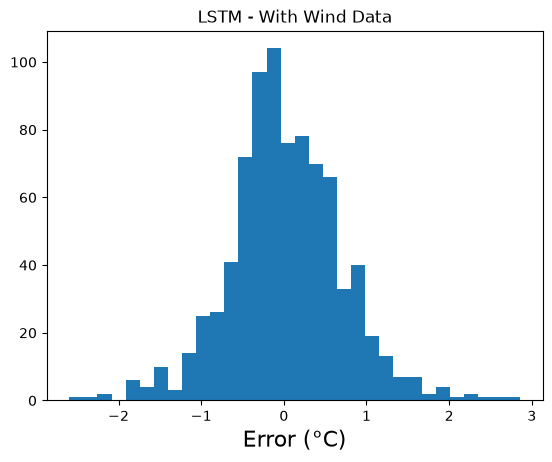

In [59]:
plt.hist(test_x_df.errors, bins='auto')
plt.title('LSTM - With Wind Data')
plt.xlabel('Error (\u00b0C)', fontsize=16)
plt.show()

In [60]:
pd.DataFrame(test_x_df.errors.describe()).T

,count,mean,std,min,25%,50%,75%,max
errors,827.0,0.025588,0.688151,-2.595779,-0.372984,-0.019864,0.442926,2.859166


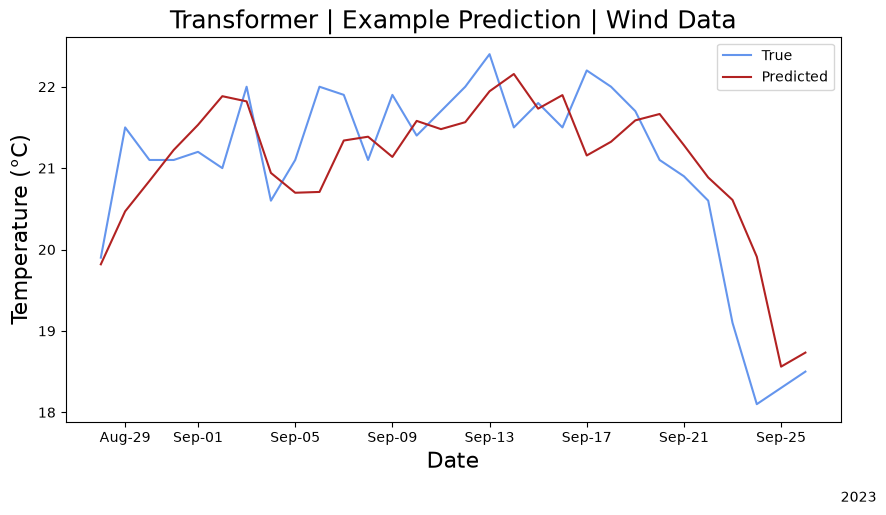

In [61]:
plot_df = test_x_df[:30].copy()
fig, ax = plt.subplots(figsize=(10,5))

ax.plot(plot_df.date, plot_df.actual, label='True', color='cornflowerblue')
ax.plot(plot_df.date, plot_df.predicted, label='Predicted', color='firebrick')
ax.set_ylabel('Temperature (\u00b0C)', fontsize=16)
ax.set_xlabel('Date', fontsize=16)
ax.set_title('Transformer | Example Prediction | Wind Data', fontsize=18)
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%d'))
fig.text(.9, -.05, f'{int(plot_df.year.unique()[0])}')
plt.show()

In [62]:
mse = np.mean([x**2 for x in test_x_df.errors])
rmse = np.sqrt(mse)
r_2 = r2_score(y_seq_test.squeeze(), y_pred)

print(f'RMSE = {round(rmse, 2)}')
print(f'r2 score = {round(r_2, 2)}')

RMSE = 0.69
r2 score = 0.94


The RMSE was 0.69 and the r2 score was 0.94. This is the best performing model so far.